# The Price is Right

Today we build a more complex solution for estimating prices of goods.

1. Day 2.0 notebook: create a RAG database with our 400,000 training data
2. Day 2.1 notebook: visualize in 2D
3. Day 2.2 notebook: visualize in 3D
4. Day 2.3 notebook: build and test a RAG pipeline with GPT-4o-mini
5. Day 2.4 notebook: (a) bring back our Random Forest pricer (b) Create a Ensemble pricer that allows contributions from all the pricers

Phew! That's a lot to get through in one day!

## PLEASE NOTE:

We already have a very powerful product estimator with our proprietary, fine-tuned LLM. Most people would be very satisfied with that! The main reason we're adding these extra steps is to deepen your expertise with RAG and with Agentic workflows.

## Finishing off with Random Forests & Ensemble

In [4]:
# imports

import os
import re
import math
import json
from tqdm import tqdm
import random
from dotenv import load_dotenv
from huggingface_hub import login
import numpy as np
import pickle
from openai import OpenAI
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
import chromadb
from items import Item
from testing import Tester
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib


In [3]:
# CONSTANTS

QUESTION = "How much does this cost to the nearest dollar?\n\n"
DB = "products_vectorstore"

In [2]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HUGGING_FACE_TOKEN_WITH_LLAMA_ACCESS', 'your-key-if-not-using-env')

In [17]:
# Load in the test pickle file:

with open('../week6/test.pkl', 'rb') as file:
    test = pickle.load(file)

In [6]:
client = chromadb.PersistentClient(path=DB)
collection = client.get_or_create_collection('products')

In [7]:
result = collection.get(include=['embeddings', 'documents', 'metadatas'])
vectors = np.array(result['embeddings'])
documents = result['documents']
prices = [metadata['price'] for metadata in result['metadatas']]

# Random Forest

We will now train a Random Forest model.

Can you spot the difference from what we did in Week 6? In week 6 we used the word2vec model to form vectors; this time we'll use the vectors we already have in Chroma, from the SentenceTransformer model.

In [8]:
# This next line takes an hour on my M1 Mac!

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(vectors, prices)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
# Save the model to a file

joblib.dump(rf_model, 'random_forest_model.pkl')

['random_forest_model.pkl']

In [10]:
# Load it back in again

rf_model = joblib.load('random_forest_model.pkl')

In [11]:
from agents.specialist_agent import SpecialistAgent
from agents.frontier_agent import FrontierAgent
from agents.random_forest_agent import RandomForestAgent

In [12]:
specialist = SpecialistAgent()
frontier = FrontierAgent(collection)
random_forest = RandomForestAgent()

/opt/homebrew/Caskroom/miniforge/base/envs/llms/lib/python3.11/asyncio/events.py:84: DeprecationError: 2025-01-27: `modal.Cls.lookup` is deprecated and will be removed in a future release. It can be replaced with `modal.Cls.from_name`.

See https://modal.com/docs/guide/modal-1-0-migration for more information.
  self._context.run(self._callback, *self._args)


In [13]:
def description(item):
    return item.prompt.split("to the nearest dollar?\n\n")[1].split("\n\nPrice is $")[0]

In [14]:
def rf(item):
    return random_forest.price(description(item))

1: Guess: $110.47 Truth: $28.95 Error: $81.52 SLE: 1.73 Item: Arch Memory AM-D3NS1866L-4G 4GB 204-Pin ...
2: Guess: $89.84 Truth: $25.99 Error: $63.85 SLE: 1.47 Item: Dreamus LIGHTSUM - Into The Light 1st Mi...
3: Guess: $101.97 Truth: $260.00 Error: $158.03 SLE: 0.87 Item: Belden 1613AP, Plenum Rated RG6 Coaxial ...
4: Guess: $205.62 Truth: $419.99 Error: $214.37 SLE: 0.51 Item: Garmin Enduro, Ultraperformance Multispo...
5: Guess: $120.81 Truth: $279.99 Error: $159.18 SLE: 0.70 Item: JOYLDIAS Kids Ride On Police Car, 12V Ba...
6: Guess: $83.30 Truth: $62.02 Error: $21.28 SLE: 0.08 Item: Middle Atlantic Products The Brush Gromm...
7: Guess: $327.22 Truth: $190.49 Error: $136.73 SLE: 0.29 Item: Canon EF-M 22mm f2 STM Compact System Fi...
8: Guess: $215.21 Truth: $120.99 Error: $94.22 SLE: 0.33 Item: VideoSecu 700TVL Day Night IR CCTV Wide ...
9: Guess: $180.87 Truth: $153.67 Error: $27.20 SLE: 0.03 Item: Pioneer Pioneer SE-M521 Headphone Sealed...
10: Guess: $218.21 Truth: $91.99 Error

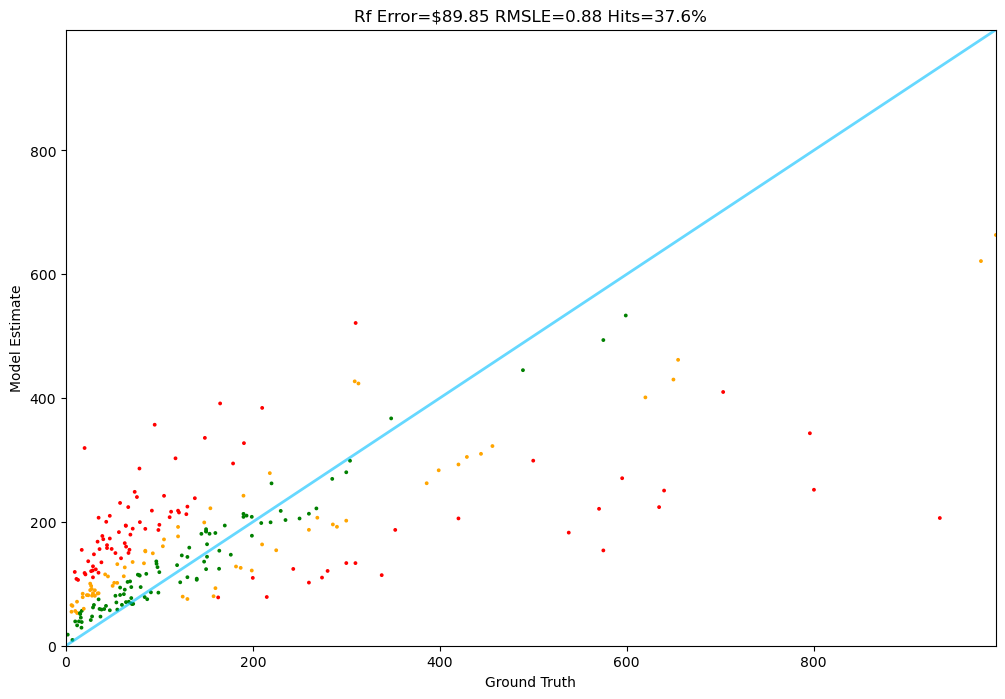

In [18]:
Tester.test(rf, test)

In [19]:
product = "Quadcast HyperX condenser mic for high quality audio for podcasting"

In [20]:
print(specialist.price(product))
print(frontier.price(product))
print(random_forest.price(product))

84.0
119.99
211.98500000000016


In [21]:
specialists = []
frontiers = []
random_forests = []
prices = []
for item in tqdm(test[1000:1250]):
    text = description(item)
    specialists.append(specialist.price(text))
    frontiers.append(frontier.price(text))
    random_forests.append(random_forest.price(text))
    prices.append(item.price)

100%|██████████| 250/250 [22:18<00:00,  5.36s/it]


In [22]:
mins = [min(s,f,r) for s,f,r in zip(specialists, frontiers, random_forests)]
maxes = [max(s,f,r) for s,f,r in zip(specialists, frontiers, random_forests)]

X = pd.DataFrame({
    'Specialist': specialists,
    'Frontier': frontiers,
    'RandomForest': random_forests,
    'Min': mins,
    'Max': maxes,
})

# Convert y to a Series
y = pd.Series(prices)

In [27]:
X.head(2)
y.head(2)

0    179.99
1     28.99
dtype: float64

In [28]:
# Train a Linear Regression
np.random.seed(42)

lr = LinearRegression()
lr.fit(X, y)

feature_columns = X.columns.tolist()

for feature, coef in zip(feature_columns, lr.coef_):
    print(f"{feature}: {coef:.2f}")
print(f"Intercept={lr.intercept_:.2f}")

Specialist: 0.83
Frontier: 0.66
RandomForest: 0.61
Min: -1.13
Max: -0.18
Intercept=-1.69


In [29]:
joblib.dump(lr, 'ensemble_model.pkl')

['ensemble_model.pkl']

In [30]:
from agents.ensemble_agent import EnsembleAgent
ensemble = EnsembleAgent(collection)

/opt/homebrew/Caskroom/miniforge/base/envs/llms/lib/python3.11/asyncio/events.py:84: DeprecationError: 2025-01-27: `modal.Cls.lookup` is deprecated and will be removed in a future release. It can be replaced with `modal.Cls.from_name`.

See https://modal.com/docs/guide/modal-1-0-migration for more information.
  self._context.run(self._callback, *self._args)


In [31]:
ensemble.price(product)

144.09892556433806

In [32]:
def ensemble_pricer(item):
    return max(0,ensemble.price(description(item)))

1: Guess: $57.34 Truth: $28.95 Error: $28.39 SLE: 0.44 Item: Arch Memory AM-D3NS1866L-4G 4GB 204-Pin ...
2: Guess: $51.09 Truth: $25.99 Error: $25.10 SLE: 0.43 Item: Dreamus LIGHTSUM - Into The Light 1st Mi...
3: Guess: $197.94 Truth: $260.00 Error: $62.06 SLE: 0.07 Item: Belden 1613AP, Plenum Rated RG6 Coaxial ...
4: Guess: $577.78 Truth: $419.99 Error: $157.79 SLE: 0.10 Item: Garmin Enduro, Ultraperformance Multispo...
5: Guess: $239.13 Truth: $279.99 Error: $40.86 SLE: 0.02 Item: JOYLDIAS Kids Ride On Police Car, 12V Ba...
6: Guess: $80.35 Truth: $62.02 Error: $18.33 SLE: 0.07 Item: Middle Atlantic Products The Brush Gromm...
7: Guess: $294.41 Truth: $190.49 Error: $103.92 SLE: 0.19 Item: Canon EF-M 22mm f2 STM Compact System Fi...
8: Guess: $173.61 Truth: $120.99 Error: $52.62 SLE: 0.13 Item: VideoSecu 700TVL Day Night IR CCTV Wide ...
9: Guess: $126.67 Truth: $153.67 Error: $27.00 SLE: 0.04 Item: Pioneer Pioneer SE-M521 Headphone Sealed...
10: Guess: $141.04 Truth: $91.99 Error: $

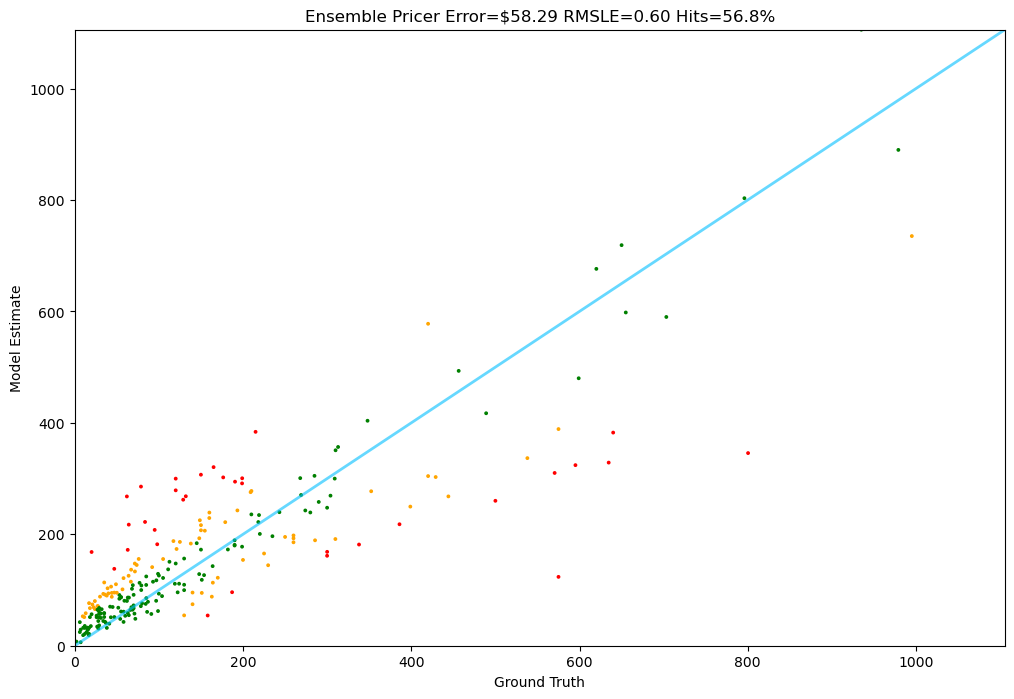

In [34]:
Tester.test(ensemble_pricer, test)

# WHAT A DAY!

We got so much done - a Fronter RAG pipeline, a Random Forest model using transformer-based encodings, and an Ensemble model.

You can do better, for sure!

Tweak this, and try adding components into the ensemble, to beat my performance.